# DesInventar — Data Quality Findings
### Montandon ETL · prepared for IFRC & Algo8

---

**In one line:** DesInventar publishes 908,446 disaster records. Montandon holds 553,062 of them.
The missing 39% was not missing at the source — we lost it, and every failure reported success.

This review was triggered by two questions from Algo8:

1. *African disaster records collapse after 2023 — is DesInventar reporting late?*
2. *Why do the collection counts not line up?*

The answer to the first is **no** — the recent data exists and is fine. The answer to the
second is that five defects in our own pipeline silently discard a third of the source.

Everything below is measured from a complete re-download of all 100 DesInventar country
archives, audited row by row against the transformer's own logic.


In [1]:
import warnings

warnings.filterwarnings("ignore")
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
from matplotlib.patches import Patch

DATA = Path("../data/desinventar_eda")
pipeline = pd.read_csv(DATA / "pipeline.csv")
audit = pd.read_csv(DATA / "source_audit.csv")
hazards = pd.read_csv(DATA / "hazard_unmapped.csv")
items = pd.read_parquet(DATA / "items.parquet")
events = items[items.item_type == "Event"].copy()
impacts = items[items.item_type == "Impact"]

BLUE, ORANGE, RED, AMBER, GREEN, GREY = "#2a78d6", "#eb6834", "#b3261e", "#a86400", "#1f7a45", "#98a2b3"
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "font.size": 9,
        "axes.grid": True,
        "grid.alpha": 0.2,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titlesize": 11,
        "axes.titleweight": "bold",
        "figure.facecolor": "white",
    }
)
thousands = mticker.FuncFormatter(lambda x, _: f"{x:,.0f}")

src_rows = int(audit.source_rows.sum())
would = int(audit.kept.sum())
loaded = len(events)
no_tr = set(pipeline[~pipeline.has_transform].country_code)
zero_tr = set(pipeline[(pipeline.has_transform) & (pipeline.total_rows == 0)].country_code)
never = int(audit[audit.country_code.isin(no_tr)].kept.sum())
silent = int(audit[audit.country_code.isin(zero_tr)].kept.sum())
valerr = int(audit.get("exception_ValidationError", pd.Series(dtype=float)).fillna(0).sum())
keyerr = int(audit.get("exception_KeyError", pd.Series(dtype=float)).fillna(0).sum())
unmapped = int(audit.hazard_unmapped.sum())
baddate = int(audit.bad_date.sum())
print(f"{src_rows:,} source rows   ->   {loaded:,} events in Montandon   ({100 * (src_rows - loaded) / src_rows:.1f}% lost)")

908,446 source rows   ->   553,062 events in Montandon   (39.1% lost)


## 1. Where the data goes

Every block of colour except the blue one is data DesInventar published and we did not keep.


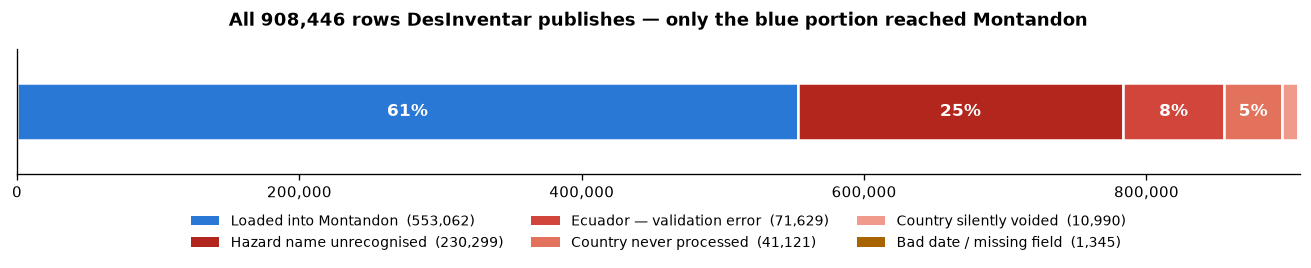

In [2]:
seg = [
    ("Loaded into Montandon", loaded, BLUE),
    ("Hazard name unrecognised", unmapped, RED),
    ("Ecuador — validation error", valerr, "#d1453b"),
    ("Country never processed", never, "#e2725b"),
    ("Country silently voided", silent, "#ef9a8a"),
    ("Bad date / missing field", baddate + keyerr, AMBER),
]

fig, ax = plt.subplots(figsize=(11, 2.5))
left = 0
for name, val, col in seg:
    ax.barh([0], [val], left=left, color=col, height=0.55, edgecolor="white", linewidth=1.5)
    if val / src_rows > 0.045:
        ax.text(
            left + val / 2,
            0,
            f"{100 * val / src_rows:.0f}%",
            ha="center",
            va="center",
            color="white",
            fontweight="bold",
            fontsize=10,
        )
    left += val
ax.set_xlim(0, src_rows)
ax.set_ylim(-0.6, 0.6)
ax.set_yticks([])
ax.grid(False)
ax.xaxis.set_major_formatter(thousands)
ax.set_title(f"All {src_rows:,} rows DesInventar publishes — only the blue portion reached Montandon", pad=14)
ax.legend(
    handles=[Patch(facecolor=c, label=f"{n}  ({v:,})") for n, v, c in seg],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.22),
    ncol=3,
    frameon=False,
    fontsize=8.5,
)
plt.tight_layout()
plt.show()

## 2. Countries drop out at every stage

27 of the 100 country codes we ask for end up contributing nothing at all.


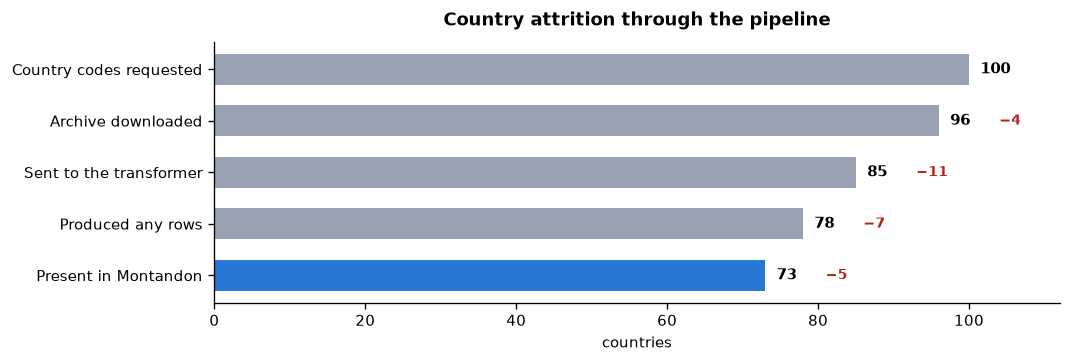

Downloaded OK but never sent to the transformer : 005, 019, 033, tur, tza, vct, vnm, xkx, yem, zmb, znz
Dead URLs at the source (404)                   : etm, mal, prt, sy11
Empty or unreadable at the source               : blr, lao, mmr
Had data, reported success, produced nothing    : mar, mdv, som, syr


In [3]:
stages = [
    ("Country codes requested", len(pipeline), GREY),
    ("Archive downloaded", int((pipeline.resp_code == 200).sum()), GREY),
    ("Sent to the transformer", int(pipeline.has_transform.sum()), GREY),
    ("Produced any rows", int((pipeline.total_rows > 0).sum()), GREY),
    ("Present in Montandon", events.country_code.nunique(), BLUE),
]
names = [s[0] for s in stages]
vals = [s[1] for s in stages]
cols = [s[2] for s in stages]

fig, ax = plt.subplots(figsize=(9, 3.1))
ax.barh(names, vals, color=cols, height=0.6)
ax.invert_yaxis()
ax.grid(False)
ax.set_xlim(0, 112)
for i, v in enumerate(vals):
    ax.text(v + 1.5, i, f"{v}", va="center", fontweight="bold")
    if i:
        d = vals[i - 1] - v
        if d:
            ax.text(v + 8, i, f"−{d}", va="center", color=RED, fontsize=8.5, fontweight="bold")
ax.set_title("Country attrition through the pipeline", pad=10)
ax.set_xlabel("countries")
plt.tight_layout()
plt.show()

dl_skipped = sorted(pipeline[(pipeline.resp_code == 200) & (~pipeline.has_transform)].country_code)
dead_url = sorted(pipeline[pipeline.resp_code != 200].country_code)
empty_src = sorted(audit[(audit.source_rows == 0) | (audit.error.fillna("") != "")].country_code)
voided = sorted(set(zero_tr) - set(empty_src))
print("Downloaded OK but never sent to the transformer :", ", ".join(dl_skipped))
print("Dead URLs at the source (404)                   :", ", ".join(dead_url))
print("Empty or unreadable at the source               :", ", ".join(empty_src))
print("Had data, reported success, produced nothing    :", ", ".join(voided))

## 3. The recent-year 'collapse' is not real

Algo8 measured 202 African events for 2024 and 89 for 2025, and reasonably read that as
DesInventar reporting late. A fresh pull finds the data is there — what they queried was
simply a stale copy. 2025 and 2026 are genuinely partial, which is normal reporting lag.


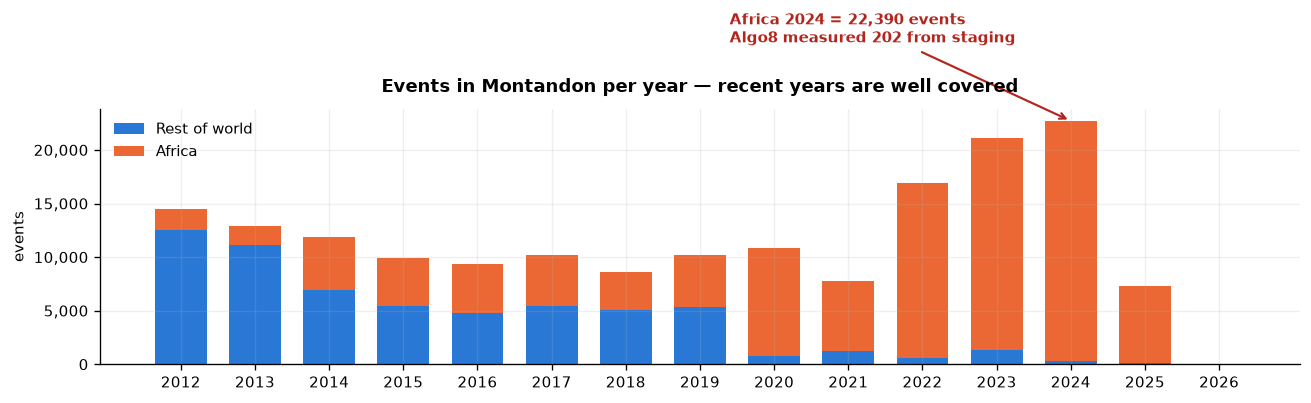

Africa 2024 — Algo8: 202   |   this pull: 22,390   (111x more)


In [4]:
AFRICA = {
    "ago",
    "bfa",
    "bdi",
    "com",
    "cpv",
    "dji",
    "egy",
    "eth",
    "gha",
    "gin",
    "gmb",
    "gnb",
    "gnq",
    "ken",
    "lbr",
    "mdg",
    "mli",
    "moz",
    "mus",
    "mwi",
    "nam",
    "ner",
    "nga",
    "rwa",
    "sdn",
    "sen",
    "sle",
    "som",
    "swz",
    "syc",
    "tgo",
    "tza",
    "uga",
    "zmb",
    "znz",
    "mar",
    "tun",
}
yr = (
    events[events.year.between(2012, 2026)]
    .assign(af=lambda d: d.country_code.isin(AFRICA))
    .groupby(["year", "af"])
    .size()
    .unstack(fill_value=0)
    .rename(columns={True: "Africa", False: "Rest of world"})
)

fig, ax = plt.subplots(figsize=(11, 3.6))
ax.bar(yr.index, yr["Rest of world"], color=BLUE, width=0.7, label="Rest of world")
ax.bar(yr.index, yr["Africa"], bottom=yr["Rest of world"], color=ORANGE, width=0.7, label="Africa")
ax.set_xticks(list(yr.index))
ax.yaxis.set_major_formatter(thousands)
ax.set_title("Events in Montandon per year — recent years are well covered", pad=10)
ax.set_ylabel("events")
ax.legend(frameon=False, loc="upper left")
a24 = int(yr.loc[2024, "Africa"])
ax.annotate(
    f"Africa 2024 = {a24:,} events\nAlgo8 measured 202 from staging",
    xy=(2024, yr.loc[2024].sum()),
    xytext=(2019.4, yr.max().sum() * 0.86),
    arrowprops=dict(arrowstyle="->", color=RED, lw=1.3),
    color=RED,
    fontsize=9,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

print(f"Africa 2024 — Algo8: 202   |   this pull: {a24:,}   ({a24 / 202:.0f}x more)")

## 4. The loss is wildly uneven between countries

This is why a single '39%' figure is misleading. Eight countries lose *everything*;
others are almost clean. Each pattern needs a different fix.


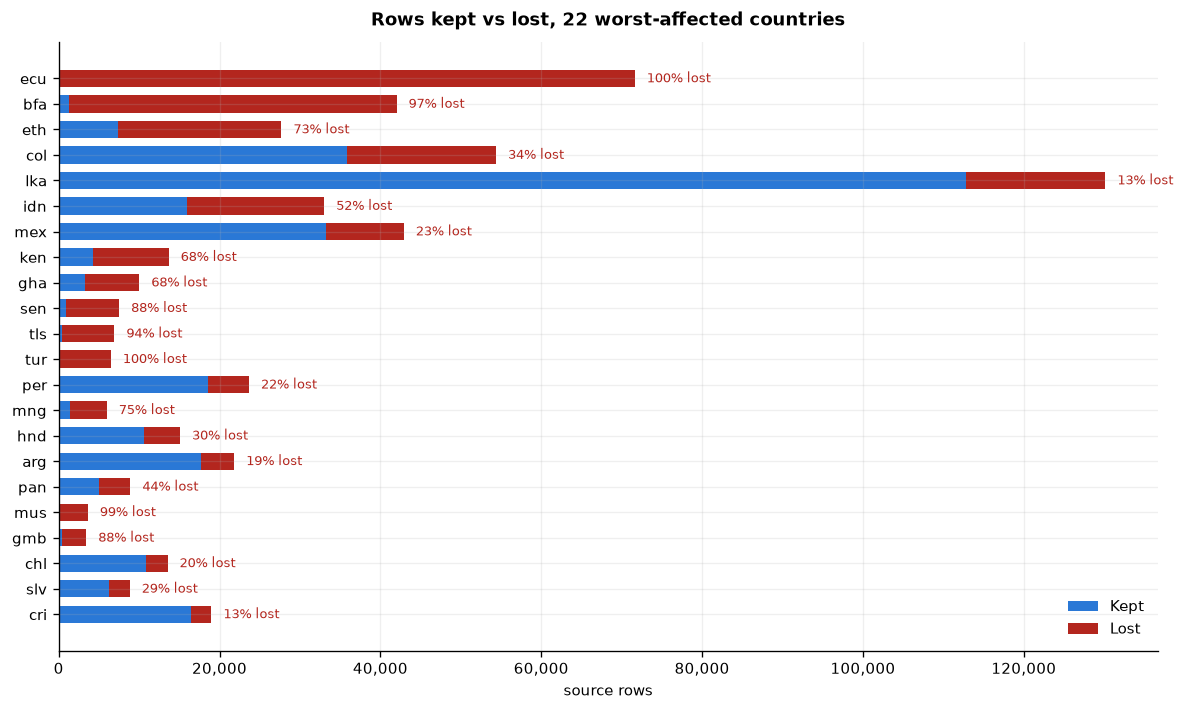

Countries losing 100%: ecu, lbn, mar, pac, sle, tgo, tur, vnm


In [5]:
w = audit.assign(lost=lambda d: d.source_rows - d.kept)
w = w[w.source_rows > 0].nlargest(22, "lost")
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(w.country_code, w.kept, color=BLUE, height=0.68, label="Kept")
ax.barh(w.country_code, w.lost, left=w.kept, color=RED, height=0.68, label="Lost")
ax.invert_yaxis()
ax.xaxis.set_major_formatter(thousands)
for i, (k, l, t) in enumerate(zip(w.kept, w.lost, w.source_rows)):
    ax.text(t + t.max() * 0.004 if False else t + 1500, i, f"{100 * l / t:.0f}% lost", va="center", fontsize=8, color=RED)
ax.set_title("Rows kept vs lost, 22 worst-affected countries", pad=10)
ax.set_xlabel("source rows")
ax.legend(frameon=False, loc="lower right")
plt.tight_layout()
plt.show()

tot = audit[audit.source_rows > 0]
print("Countries losing 100%:", ", ".join(sorted(tot[tot.kept == 0].country_code)))

## 5. The single biggest cause is spelling

Hazard names are matched against a fixed list, exactly. `FORESTFIRE` does not match
`FOREST FIRE`, so those records are discarded. A quarter of all losses are variants of
names the system already knows — recoverable with no judgement calls.


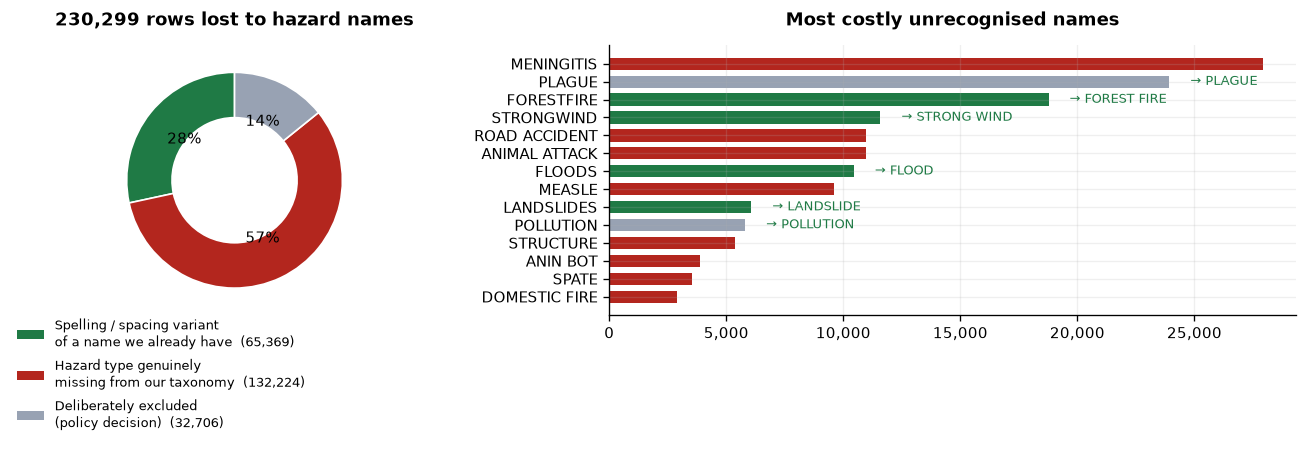

In [6]:
cls = (
    hazards.groupby("classification")
    .rows.sum()
    .reindex(["recoverable_by_normalisation", "missing_from_taxonomy", "explicitly_mapped_to_none"])
    .fillna(0)
)
labels = [
    "Spelling / spacing variant\nof a name we already have",
    "Hazard type genuinely\nmissing from our taxonomy",
    "Deliberately excluded\n(policy decision)",
]
fig, axes = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={"width_ratios": [1, 1.35]})
axes[0].pie(
    cls.values,
    labels=None,
    colors=[GREEN, RED, GREY],
    autopct="%1.0f%%",
    startangle=90,
    wedgeprops=dict(width=0.42, edgecolor="white"),
    textprops=dict(fontsize=9),
)
axes[0].legend(
    handles=[Patch(facecolor=c, label=f"{l}  ({int(v):,})") for l, v, c in zip(labels, cls.values, [GREEN, RED, GREY])],
    loc="center left",
    bbox_to_anchor=(-0.35, -0.22),
    frameon=False,
    fontsize=8,
)
axes[0].set_title(f"{int(cls.sum()):,} rows lost to hazard names", pad=12)

top = hazards.nlargest(14, "rows").iloc[::-1]
cmap = {"recoverable_by_normalisation": GREEN, "missing_from_taxonomy": RED, "explicitly_mapped_to_none": GREY}
axes[1].barh(top.hazard_name, top.rows, color=[cmap[c] for c in top.classification], height=0.68)
axes[1].xaxis.set_major_formatter(thousands)
axes[1].set_title("Most costly unrecognised names", pad=12)
for i, (n, c, t) in enumerate(zip(top.rows, top.classification, top.normalises_to.fillna(""))):
    axes[1].text(n + 900, i, f"→ {t}" if t else "", va="center", fontsize=7.5, color=GREEN)
plt.tight_layout()
plt.show()

## 6. Two thirds of locations are a whole country

When a record's local administrative boundary can't be resolved, we fall back to the
outline of the entire country. Without that fallback these records would have no location
at all — but a nationwide polygon on a village-level flood is a large loss of precision,
and it is now the majority case.


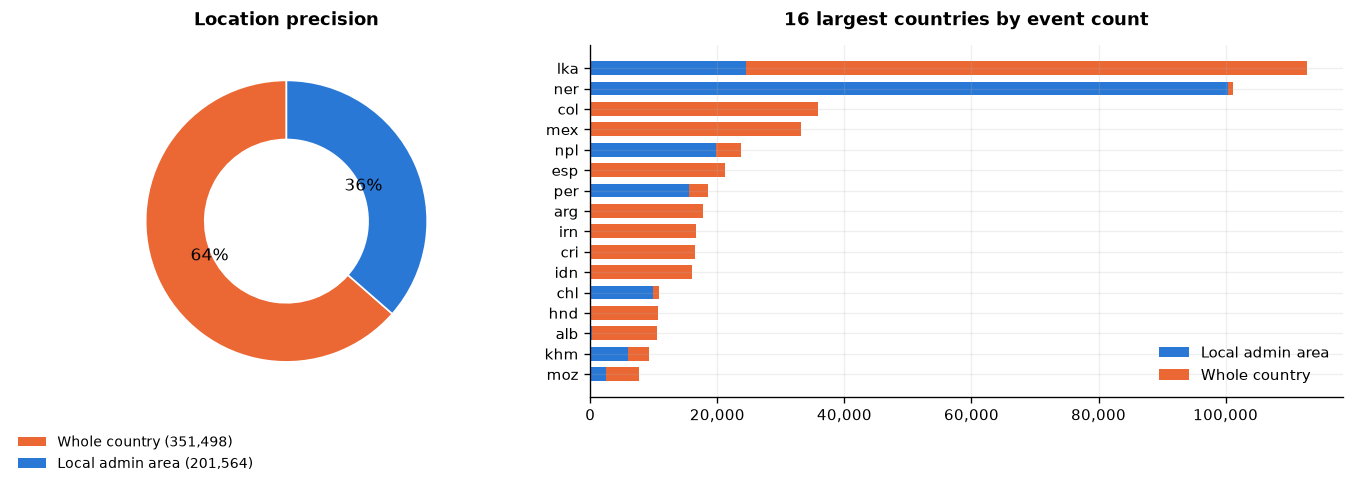

42 of 73 countries have no local geometry at all.


In [7]:
ev = events.copy()
ev["area"] = (ev.bbox_maxx - ev.bbox_minx).abs() * (ev.bbox_maxy - ev.bbox_miny).abs()
ev["key"] = ev[["bbox_minx", "bbox_miny", "bbox_maxx", "bbox_maxy"]].round(5).astype(str).agg("|".join, axis=1)
g = []
for cc, grp in ev.groupby("country_code"):
    big = grp.loc[grp.area.idxmax(), "key"]
    g.append({"cc": cc, "events": len(grp), "country_level": int((grp.key == big).sum())})
geo = pd.DataFrame(g)
geo["admin_level"] = geo.events - geo.country_level

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), gridspec_kw={"width_ratios": [1, 1.5]})
tot_c, tot_a = int(geo.country_level.sum()), int(geo.admin_level.sum())
axes[0].pie(
    [tot_c, tot_a],
    colors=[ORANGE, BLUE],
    autopct="%1.0f%%",
    startangle=90,
    wedgeprops=dict(width=0.42, edgecolor="white"),
    textprops=dict(fontsize=10),
)
axes[0].set_title("Location precision", pad=12)
axes[0].legend(
    handles=[
        Patch(facecolor=ORANGE, label=f"Whole country ({tot_c:,})"),
        Patch(facecolor=BLUE, label=f"Local admin area ({tot_a:,})"),
    ],
    loc="center left",
    bbox_to_anchor=(-0.3, -0.16),
    frameon=False,
    fontsize=8.5,
)
t = geo.nlargest(16, "events").iloc[::-1]
axes[1].barh(t.cc, t.admin_level, color=BLUE, height=0.68, label="Local admin area")
axes[1].barh(t.cc, t.country_level, left=t.admin_level, color=ORANGE, height=0.68, label="Whole country")
axes[1].xaxis.set_major_formatter(thousands)
axes[1].legend(frameon=False, loc="lower right")
axes[1].set_title("16 largest countries by event count", pad=12)
plt.tight_layout()
plt.show()
print(f"{int((geo.admin_level == 0).sum())} of {len(geo)} countries have no local geometry at all.")

## 7. What the impact records actually contain

DesInventar records *that* a disaster happened far more often than it records *how much*
damage it caused. This one is the source being honest about what it doesn't know — not a
defect on our side, but it constrains what can be forecast from this collection.


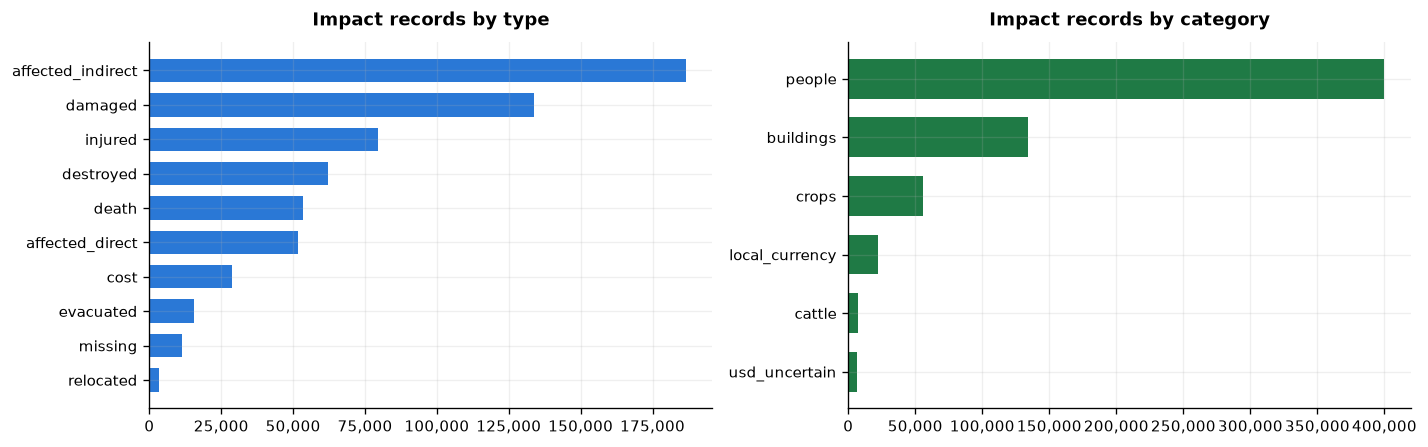

626,359 impact records for 553,062 events = 1.13 per event,
out of 14 possible measures per record — most damage fields are empty at source.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
t = impacts.impact_type.value_counts().head(10).iloc[::-1]
axes[0].barh(t.index, t.values, color=BLUE, height=0.68)
axes[0].xaxis.set_major_formatter(thousands)
axes[0].set_title("Impact records by type", pad=10)
c = impacts.impact_category.value_counts().head(10).iloc[::-1]
axes[1].barh(c.index, c.values, color=GREEN, height=0.68)
axes[1].xaxis.set_major_formatter(thousands)
axes[1].set_title("Impact records by category", pad=10)
plt.tight_layout()
plt.show()

print(f"{len(impacts):,} impact records for {len(events):,} events = {len(impacts) / len(events):.2f} per event,")
print("out of 14 possible measures per record — most damage fields are empty at source.")

## 8. Niger is not over-represented

Niger looks dominant in raw row counts, which was flagged as possible duplication. It is
not. DesInventar stores one row per affected village or district, so a single drought
legitimately spans thousands of rows sharing one episode ID. **For any analysis counting
disasters, group by episode — not by row.**


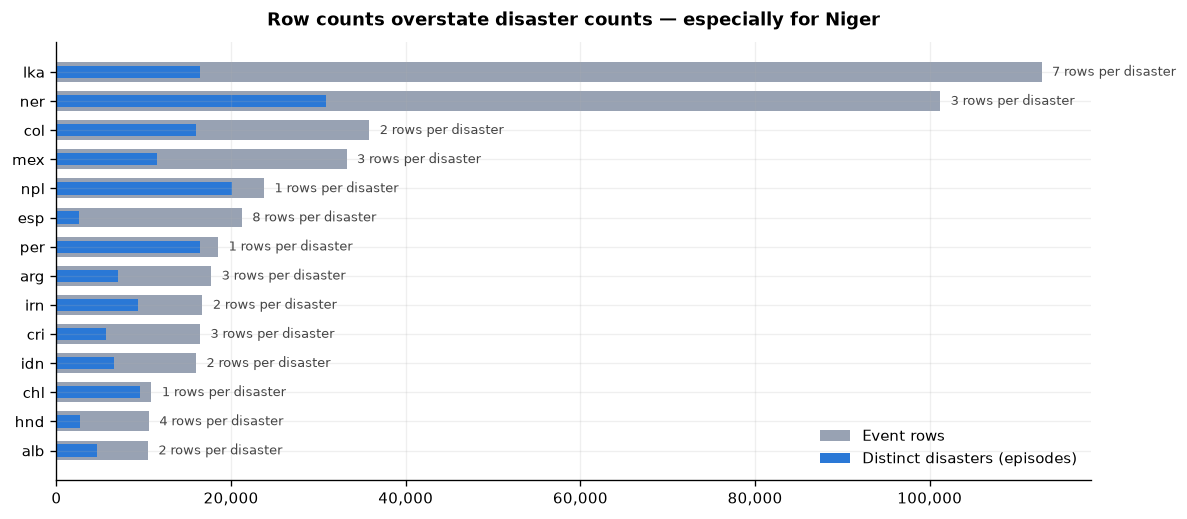

Overall: 553,062 rows describe 220,798 distinct disasters.


In [9]:
gr = (
    events.groupby("country_code")
    .agg(rows=("item_id", "size"), episodes=("corr_id", "nunique"))
    .assign(per_ep=lambda d: (d.rows / d.episodes))
    .nlargest(14, "rows")
    .iloc[::-1]
)
fig, ax = plt.subplots(figsize=(10, 4.4))
ax.barh(gr.index, gr.rows, color=GREY, height=0.68, label="Event rows")
ax.barh(gr.index, gr.episodes, color=BLUE, height=0.42, label="Distinct disasters (episodes)")
ax.xaxis.set_major_formatter(thousands)
ax.legend(frameon=False, loc="lower right")
for i, (r, e) in enumerate(zip(gr.rows, gr.per_ep)):
    ax.text(r + 1200, i, f"{e:.0f} rows per disaster", va="center", fontsize=8, color="#444")
ax.set_title("Row counts overstate disaster counts — especially for Niger", pad=10)
plt.tight_layout()
plt.show()
print(f"Overall: {len(events):,} rows describe {events.corr_id.nunique():,} distinct disasters.")

## What we are asking for

| Priority | Action | Recovers | Owner |
|---|---|---|---|
| 1 | Accept blank number fields instead of rejecting the record | 71,629 rows | Montandon |
| 2 | Match hazard names ignoring case and spacing | 65,368 rows | Montandon |
| 3 | Process the 11 downloaded countries that were skipped | 41,121 rows | Montandon |
| 4 | Stop one bad map file from voiding a whole country | 10,990 rows | Montandon |
| 5 | Make failed records report failure instead of success | — | Montandon |
| 6 | Decide how to classify 421 unmapped hazard types | 132,200 rows | **IFRC + Algo8** |

Items 1–4 are mechanical and recover **189,108 records — a 34% increase** on what Montandon
holds today, with no judgement calls. Item 6 needs a decision we cannot make alone: whether
road accidents, animal attacks, meningitis and measles outbreaks belong in this collection.

---

### Two cautions for anyone modelling this data today

**Do not read trends from the current collection.** Older records are lost at a much higher
rate than recent ones, purely because of the hazard-name defect. That gradient manufactures
a strong upward trend in disaster counts that is an artefact of our pipeline, not a signal.

**Do not treat locations as precise.** Two thirds of events currently carry a whole-country
outline rather than a local boundary.

*Measured from a complete re-download of all 100 DesInventar country archives. Audit
performed read-only; reproducible via the two management commands in `apps/etl/management/commands/`.*
